# Notebook 5 - Full Transfer Matrix

## Goal

The transfer matrix is the most compact way to show whether a truth probe generalizes across domains.

Rows are training datasets. Columns are evaluation datasets. Each cell contains grouped accuracy.

A strong universal truth signal should produce good off-diagonal performance, not just high values on the diagonal.


## Step 1 - Setup and build datasets


In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "lie_detector_llm").exists():
            return candidate
    raise RuntimeError("Could not find the project root. Run this notebook from the repository.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/imadsharof/Library/Mobile Documents/com~apple~CloudDocs/Cours/MA1/Computing Project/Lie-Detector-for-LLM


In [2]:
from lie_detector_llm.datasets import build_dataset_collection

INCLUDE_HF_DATASETS = False
MAX_HF_GROUPS = 100

collection = build_dataset_collection(
    include_hf_datasets=INCLUDE_HF_DATASETS,
    max_hf_groups=MAX_HF_GROUPS,
)

print(f"Datasets: {collection.dataset_names()}")
print(f"Total prompts: {len(collection.frame)}")
print(f"Total groups : {collection.frame['group_id'].nunique()}")


Datasets: ['cities', 'larger_than', 'qa', 'repeng_truthful']
Total prompts: 408
Total groups : 144


## Step 2 - Configure the matrix experiment

`split_evaluation=True` means each row probe trains on the train split of its training dataset and evaluates on the test split of every evaluation dataset. This makes the matrix more defensible than evaluating on the same rows used for training.


In [3]:
MODEL_NAME = "microsoft/phi-2"
LAYER_INDEX = -1
LOAD_IN_4BIT = False
ACTIVATION_BATCH_SIZE = 2

print("Matrix configuration")
print(f"Model       : {MODEL_NAME}")
print(f"Layer       : {LAYER_INDEX}")
print(f"Split eval  : True")


Matrix configuration
Model       : microsoft/phi-2
Layer       : -1
Split eval  : True


## Step 3 - Run the LR transfer matrix


In [4]:
from lie_detector_llm.experiment import run_full_transfer_matrix

lr_matrix = run_full_transfer_matrix(
    collection=collection,
    model_name=MODEL_NAME,
    probe_method="lr",
    layer_index=LAYER_INDEX,
    split_evaluation=True,
    activation_batch_size=ACTIVATION_BATCH_SIZE,
    load_in_4bit=LOAD_IN_4BIT,
    show_progress=True,
)

pivot_lr = lr_matrix.results.pivot(
    index="train_dataset",
    columns="eval_dataset",
    values="grouped_accuracy",
).round(3)

display(pivot_lr)


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/163 [00:00<?, ?it/s]

eval_dataset,cities,larger_than,qa,repeng_truthful
train_dataset,,,,
cities,1.000,0.833,0.833,1.000
larger_than,1.000,1.000,0.500,0.545
qa,1.000,0.833,0.833,1.000
repeng_truthful,0.833,0.833,0.667,1.000


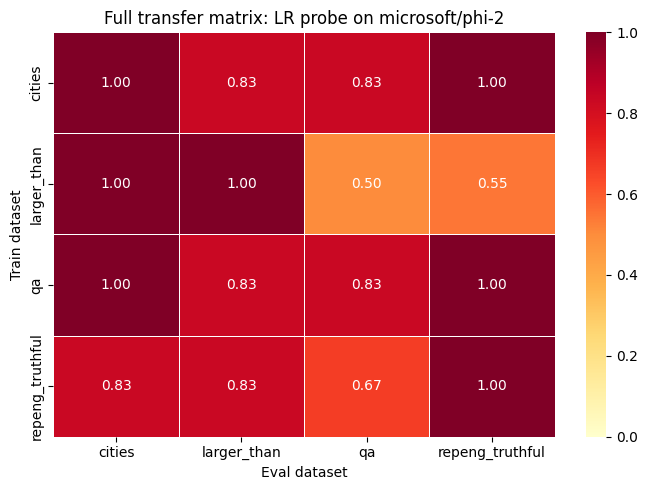

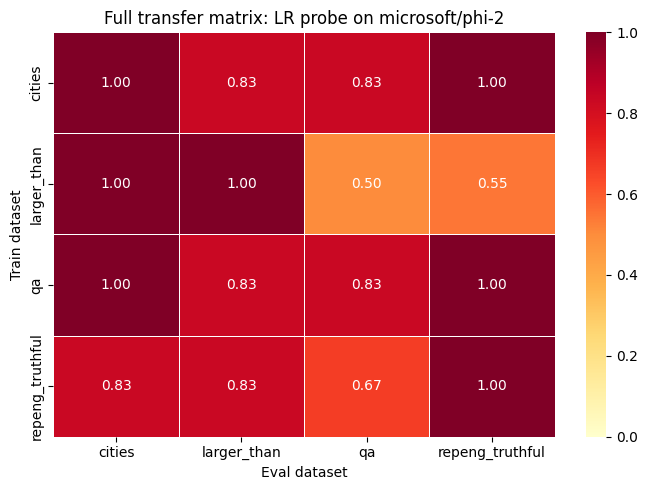

In [5]:
from lie_detector_llm.plotting import plot_transfer_heatmap

fig, ax = plot_transfer_heatmap(
    lr_matrix.results,
    title=f"Full transfer matrix: LR probe on {MODEL_NAME}",
)
fig


## Step 4 - Compare against DIM

Difference in Means is a simple direction-based baseline. Comparing LR and DIM helps distinguish strong supervised fitting from robust transfer.


In [6]:
dim_matrix = run_full_transfer_matrix(
    collection=collection,
    model_name=MODEL_NAME,
    probe_method="dim",
    layer_index=LAYER_INDEX,
    split_evaluation=True,
    activation_batch_size=ACTIVATION_BATCH_SIZE,
    load_in_4bit=LOAD_IN_4BIT,
    show_progress=True,
)

pivot_dim = dim_matrix.results.pivot(
    index="train_dataset",
    columns="eval_dataset",
    values="grouped_accuracy",
).round(3)

display(pivot_dim)


Extracting activations:   0%|          | 0/163 [00:00<?, ?it/s]

eval_dataset,cities,larger_than,qa,repeng_truthful
train_dataset,,,,
cities,1.000,0.833,0.667,0.909
larger_than,1.000,0.833,0.833,0.818
qa,1.000,0.833,0.833,0.909
repeng_truthful,0.833,0.833,0.667,0.545


## Step 5 - Compute the LR minus DIM difference matrix


In [7]:
diff = (pivot_lr - pivot_dim).round(3)
display(diff)


eval_dataset,cities,larger_than,qa,repeng_truthful
train_dataset,,,,
cities,0.0,0.000,0.166,0.091
larger_than,0.0,0.167,-0.333,-0.273
qa,0.0,0.000,0.000,0.091
repeng_truthful,0.0,0.000,0.000,0.455


Positive values mean LR performed better than DIM. Negative values mean DIM performed better.

The off-diagonal cells are the most important cells for the generalization claim.


## Step 6 - Average off-diagonal transfer for all probes


In [8]:
import pandas as pd

probe_summaries = []
for method in ["dim", "lat", "lr", "pca-g"]:
    matrix = run_full_transfer_matrix(
        collection=collection,
        model_name=MODEL_NAME,
        probe_method=method,
        layer_index=LAYER_INDEX,
        split_evaluation=True,
        activation_batch_size=ACTIVATION_BATCH_SIZE,
        load_in_4bit=LOAD_IN_4BIT,
        show_progress=True,
    )
    df_method = matrix.summary_table()
    off_diag = df_method[df_method["train_dataset"] != df_method["eval_dataset"]]
    probe_summaries.append(
        {
            "probe_method": method,
            "mean_off_diagonal_accuracy": off_diag["grouped_accuracy"].mean(),
            "min_off_diagonal_accuracy": off_diag["grouped_accuracy"].min(),
            "max_off_diagonal_accuracy": off_diag["grouped_accuracy"].max(),
        }
    )

summary = pd.DataFrame(probe_summaries).sort_values(
    "mean_off_diagonal_accuracy",
    ascending=False,
)
display(summary)


Extracting activations:   0%|          | 0/163 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/163 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/163 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/163 [00:00<?, ?it/s]

,probe_method,mean_off_diagonal_accuracy,min_off_diagonal_accuracy,max_off_diagonal_accuracy
0,dim,0.844697,0.666667,1.0
2,lr,0.823232,0.500000,1.0
3,pca-g,0.731061,0.454545,1.0
1,lat,0.640152,0.166667,1.0


## Interpretation

This notebook gives the strongest local evidence for or against generalization.

In the report, do not focus only on the best cell. Explain:

- whether diagonal performance is higher than off-diagonal performance,
- which training datasets transfer best,
- which evaluation datasets are hardest,
- whether simpler probes transfer better than supervised probes.

Notebook 6 extends this idea from one model to several LLMs.
